# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [221]:
# pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [222]:
# pip install --upgrade plotly


In [223]:
# pip install pycountry

### Import Statements

In [224]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
# from iso3166 import countries
import pycountry
from datetime import datetime, timedelta


### Notebook Presentation

In [225]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [226]:
df_data = pd.read_csv(r"C:\Users\hp\SpaceMission\mission_launches.csv")
original_df = df_data = pd.read_csv(r"C:\Users\hp\SpaceMission\mission_launches.csv")
original_df

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [227]:
print(f"Dataset consist of {df_data.shape[0]} rows and {df_data.shape[1]} colums")
print(f"columns: \n{df_data.columns}")


Dataset consist of 4324 rows and 9 colums
columns: 
Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')


In [228]:
print(f"null values:  {df_data.isna().values.any()}")
print(f"Any duplicate values:  {df_data.duplicated().any()}")
bool(df_data.isnull().values.any())

null values:  True
Any duplicate values:  False


True

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [229]:

df_data =df_data.fillna(0)
df_data.info()
df_data.head()
df_data.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           4324 non-null   object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,0,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,0,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,0,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,0,Success
4323,4323,4323,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Fri Oct 04, 1957 19:28 UTC",Sputnik 8K71PS | Sputnik-1,StatusRetired,0,Success


In [230]:
#removing junk columns
df_data = df_data.loc[:, ~df_data.columns.str.contains('^Unnamed')]
df_data

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,0,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,0,Failure
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,0,Success
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,0,Failure
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,0,Success


## Descriptive Statistics

In [231]:
df_data.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324,4324,4324,4324,4324,4324,4324
unique,56,137,4319,4278,2,57,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Wed Nov 05, 2008 00:15 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,0,Success
freq,1777,235,2,6,3534,3360,3879


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

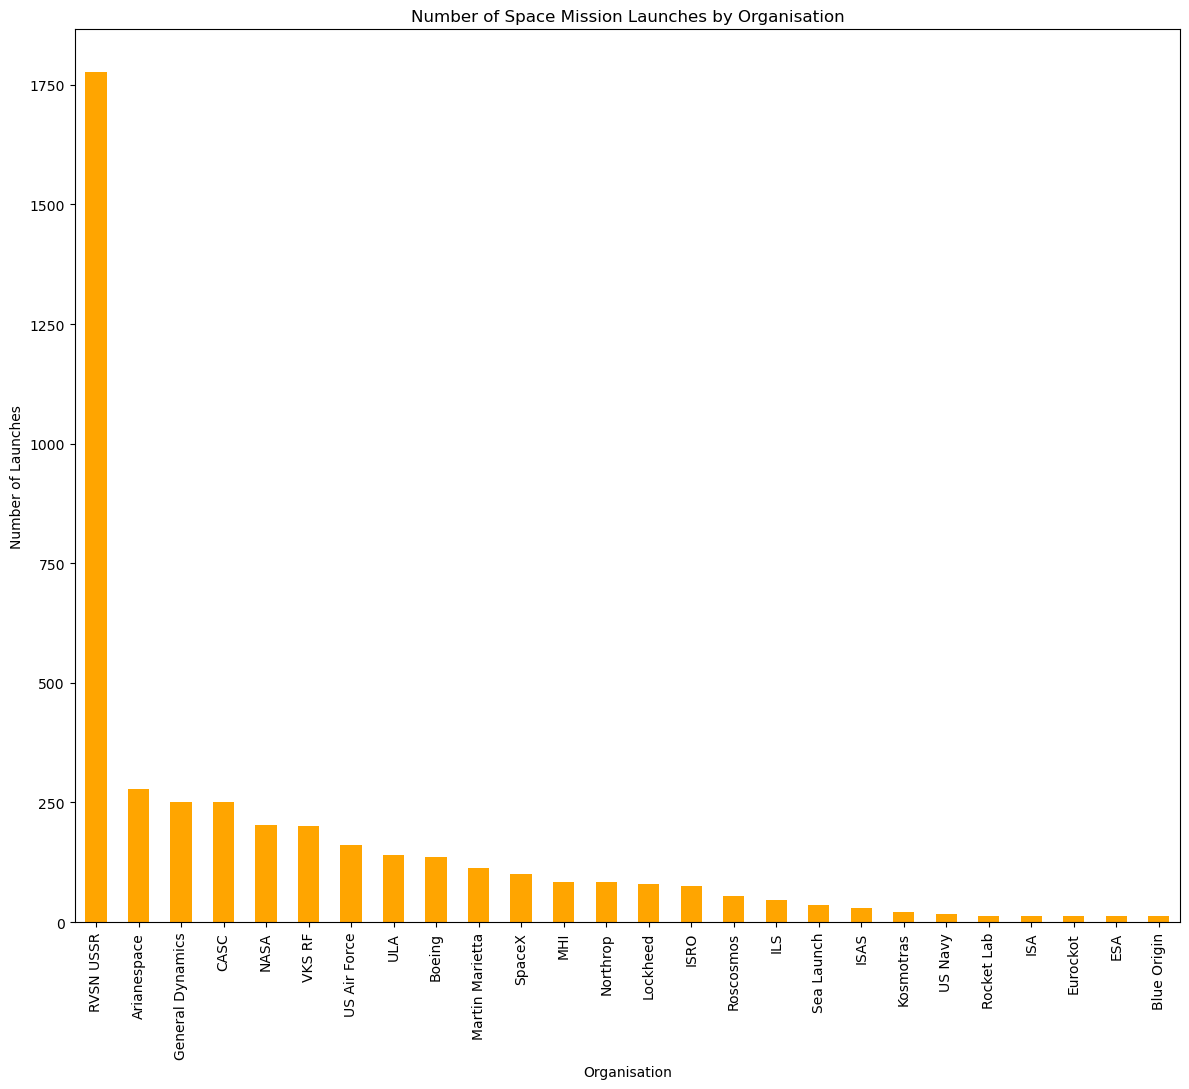

In [232]:
launches=df_data["Organisation"].value_counts()

plt.figure(figsize=(12,11))
# Create bar chart

launches[:-30].plot(kind='bar',color="orange")
plt.xlabel('Organisation')
plt.ylabel('Number of Launches')
plt.title('Number of Space Mission Launches by Organisation')
plt.tight_layout()
plt.show()



# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [233]:
status=df_data["Rocket_Status"].value_counts()


Text(0.5, 1.0, 'No of Active vs Retired Rockets')

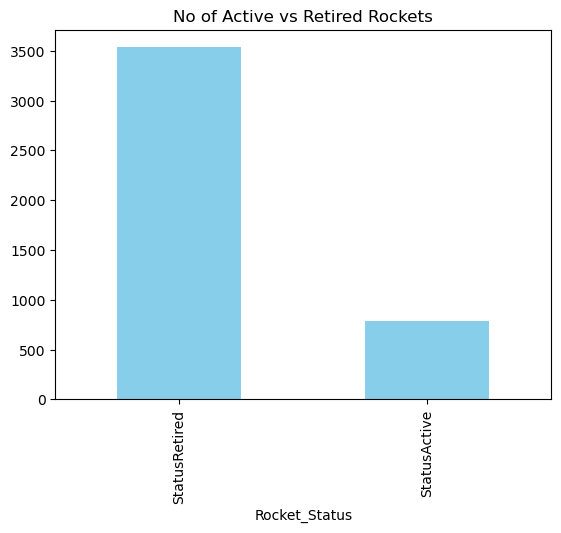

In [234]:
status.plot(kind="bar",color="skyblue")
plt.title("No of Active vs Retired Rockets")

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [235]:
mission = df_data["Mission_Status"].value_counts()
print(mission)


Mission_Status
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64


<Axes: xlabel='Mission_Status'>

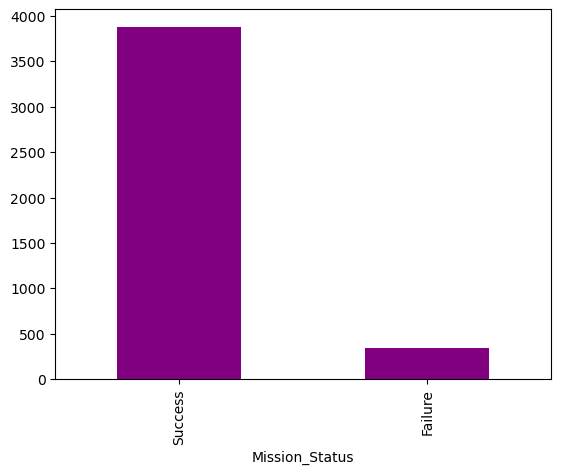

In [236]:
mission[:-2].plot(kind="bar",color="purple")

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

In [237]:


# Convert Price column to numeric (handles missing or invalid values)
price_numeric = pd.to_numeric(df_data['Price'], errors='coerce')

price_numeric   = price_numeric[ price_numeric.values > 0 ]

# price_numeric

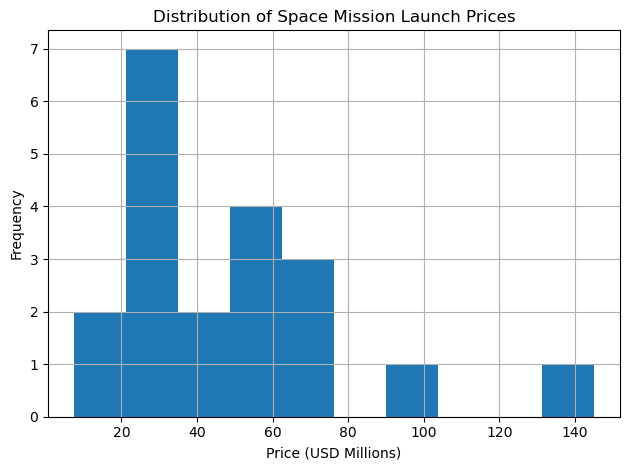

In [238]:
price_numeric[:20].hist()
plt.xlabel("Price (USD Millions)")
plt.ylabel("Frequency")
plt.title("Distribution of Space Mission Launch Prices")
plt.tight_layout()
plt.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [239]:
country_name = df_data["Location"]

country_name=country_name.astype(str).str.split(",")
country = []
for c in country_name:
    country.append(c[-1].strip())


# Create DataFrame
df_countries = pd.DataFrame(country, columns=["Country"])

def iso(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None
# Convert to ISO Alpha-3
df_countries["ISO"] = df_countries["Country"].apply(iso)
df_data["Country"] = df_countries['Country'] 
df_data["ISO"] = df_countries["ISO"]


df_data["Price"] = df_data["Price"].astype("string").str.replace(",","")
df_data["Price"] = pd.to_numeric(df_data["Price"])
final_df = df_data.groupby(["Country","ISO"],as_index=False).agg({'Price': pd.Series.count})
final_df

,Country,ISO,Price
0,Australia,AUS,6.00
1,Brazil,BRA,3.00
2,China,CHN,268.00
3,France,FRA,303.00
4,India,IND,76.00
5,Iran,IRN,13.00
6,Israel,ISR,11.00
7,Japan,JPN,126.00
8,Kazakhstan,KAZ,701.00
9,Kenya,KEN,9.00


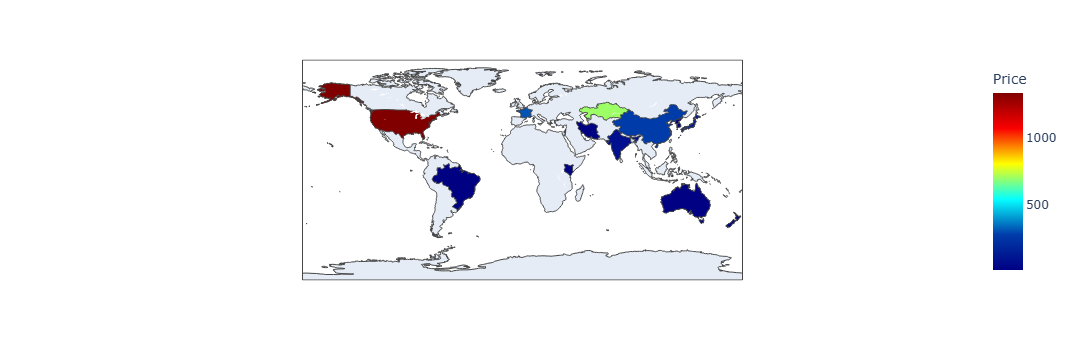

In [240]:
world_map = px.choropleth(final_df,
                          locations='ISO', 
                          color='Price',
                          hover_name= 'Country', 
                          color_continuous_scale="Jet")
 
world_map.update_layout(coloraxis_showscale=True,)
 
world_map.show()


# Use a Choropleth Map to Show the Number of Failures by Country


In [241]:
status_pivot = (
    df_data
    .groupby(["Country", "ISO", "Mission_Status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
status_pivot["Success"]

0        3
1        0
2      243
3      285
4       63
5        4
6        9
7      113
8      608
9        9
10      11
11       2
12       1
13    1186
Name: Success, dtype: int64

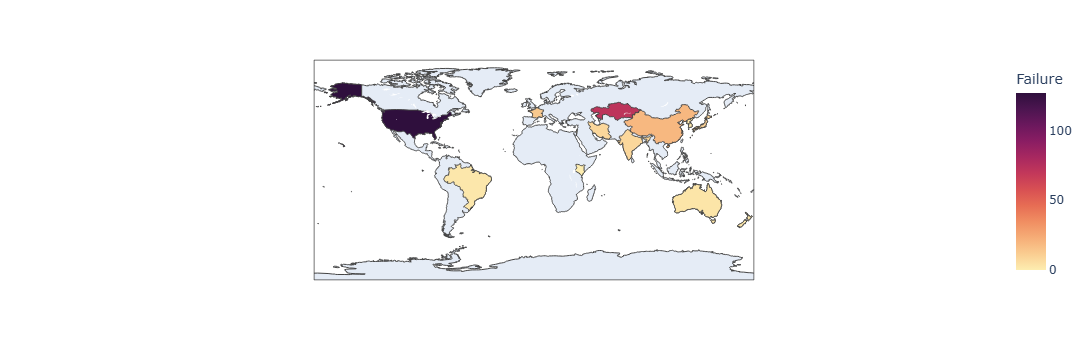

In [242]:
world_map = px.choropleth(status_pivot,
                          locations='ISO', 
                          color='Failure',
                          hover_name= 'Country', 
                          color_continuous_scale=px.colors.sequential.matter)
 
world_map.update_layout(coloraxis_showscale=True,)
 
world_map.show()


# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [243]:

graph_df = (df_data.groupby(["Country","Organisation","Mission_Status"]).size().reset_index(name='Count'))

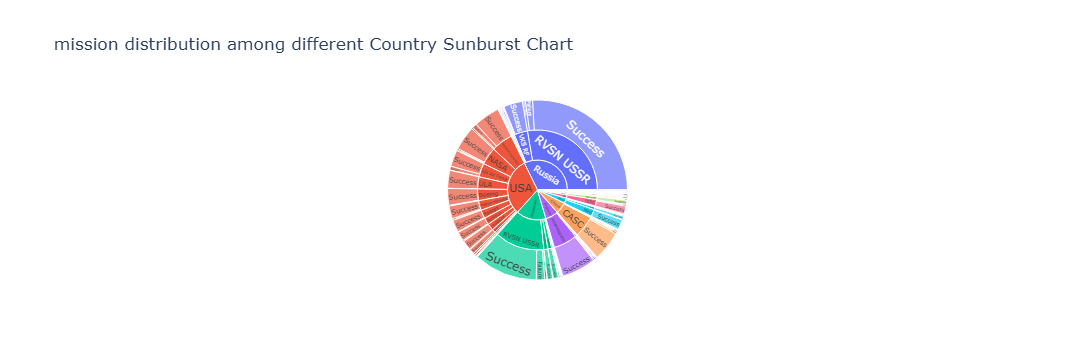

<Figure size 1300x1500 with 0 Axes>

In [244]:
plt.figure(figsize=(13,15))
fig = px.sunburst(graph_df,path=["Country","Organisation","Mission_Status"],values="Count",title=" mission distribution among different Country Sunburst Chart")
fig.show()


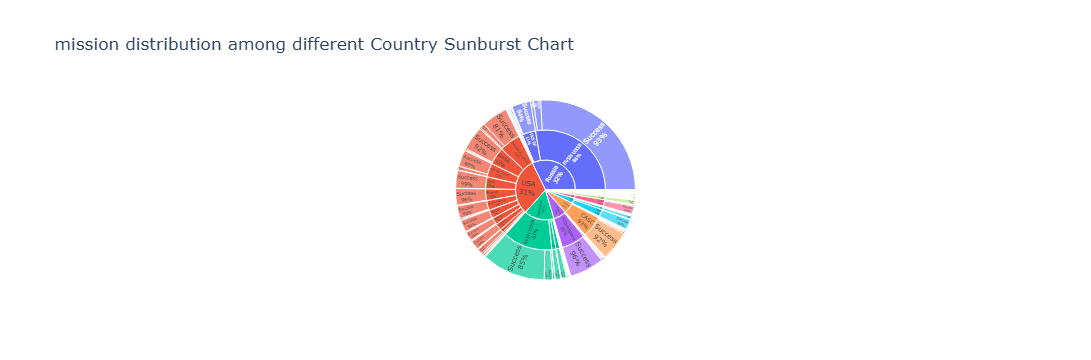

In [245]:
fig.update_traces(
    textinfo="label+percent parent",
    insidetextorientation="radial"
)


# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [246]:
Amount_spent = df_data.groupby("Organisation")["Price"].sum().reset_index(name="Total Amount")
Amount_spent=Amount_spent[Amount_spent["Total Amount"] > float(0)]
Amount_spent

,Organisation,Total Amount
3,Arianespace,"16,345.00"
6,Boeing,"1,241.00"
7,CASC,"6,340.26"
12,EER,20.00
13,ESA,37.00
14,Eurockot,543.40
15,ExPace,28.30
19,ILS,"1,320.00"
23,ISRO,"2,177.00"
24,JAXA,168.00


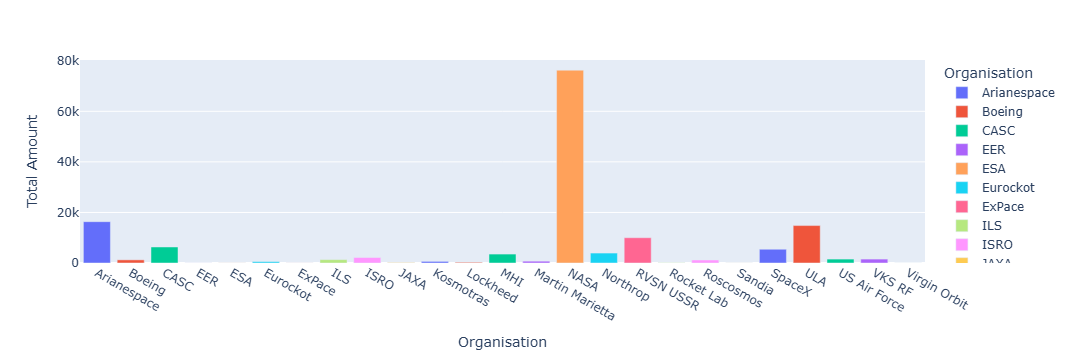

In [247]:
figs = px.bar(Amount_spent,x="Organisation",y="Total Amount",color="Organisation")
figs.show()

In [248]:
df_data.columns

Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status', 'Country', 'ISO'],
      dtype='object')

# Analyse the Amount of Money Spent by Organisation per Launch

In [249]:
# per_launch = df_data.values_count() 
print(df_data.columns)
per_launch = df_data.groupby(["Organisation","Date"])["Price"].sum().reset_index(name="Price")
per_launch = pd.DataFrame(per_launch)

per_launch = per_launch.rename(columns={"Price": "Amount_per_launch"})
per_launch.info()


per_launch


Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status', 'Country', 'ISO'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Organisation       4320 non-null   object 
 1   Date               4320 non-null   object 
 2   Amount_per_launch  4320 non-null   Float64
dtypes: Float64(1), object(2)
memory usage: 105.6+ KB


,Organisation,Date,Amount_per_launch
0,AEB,"Mon Aug 25, 2003",0.00
1,AEB,"Sat Dec 11, 1999 19:40 UTC",0.00
2,AEB,"Sun Nov 02, 1997",0.00
3,AMBA,"Sat Dec 06, 1958 05:44 UTC",0.00
4,AMBA,"Sat Feb 01, 1958 03:48 UTC",0.00
...,...,...,...
4315,VKS RF,"Wed Sep 24, 1997 21:30 UTC",0.00
4316,Virgin Orbit,"Mon May 25, 2020 19:50 UTC",12.00
4317,Yuzhmash,"Sat Nov 01, 1969 10:59 UTC",0.00
4318,Yuzhmash,"Wed Dec 18, 1991 03:54 UTC",0.00


# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

In [251]:

df_data.info()
month = df_data["Date"].astype("string").str.split(" ")
months = [m[1]+" "+m[3] for m in month]

m_launch = pd.DataFrame(months).rename(columns={0: "month-year"})

m_launch = m_launch.value_counts().reset_index(name="Total_launches")
m_launch = m_launch.query("Total_launches not in [1,2,3]").sort_values(by= "Total_launches",ascending=False )
m_launch


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Organisation    4324 non-null   object 
 1   Location        4324 non-null   object 
 2   Date            4324 non-null   object 
 3   Detail          4324 non-null   object 
 4   Rocket_Status   4324 non-null   object 
 5   Price           4324 non-null   Float64
 6   Mission_Status  4324 non-null   object 
 7   Country         4324 non-null   object 
 8   ISO             2881 non-null   object 
dtypes: Float64(1), object(8)
memory usage: 308.4+ KB


,month-year,Total_launches
0,Dec 1971,18
2,Sep 1975,16
4,Sep 1977,16
3,Dec 2019,16
1,Apr 1968,16
...,...,...
564,May 2007,4
565,May 2003,4
566,May 2002,4
567,Sep 1992,4


Text(0, 0.5, 'no. of launches')

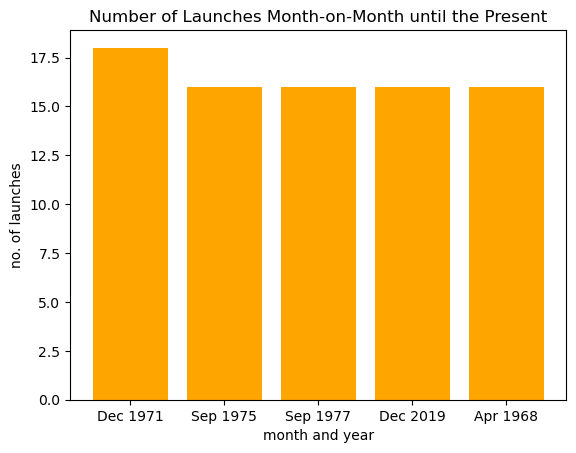

In [252]:
# plt.figure(figsize=(10,10))
plt.bar(m_launch["month-year"].head(),m_launch["Total_launches"].head(),color="orange")
plt.title("Number of Launches Month-on-Month until the Present")
plt.xlabel("month and year")
plt.ylabel("no. of launches")



# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [253]:
# max_popular = m_launch
months = [m[1] for m in month]
popular = pd.DataFrame(months).value_counts().reset_index(name="total")
popular




,0,total
0,Dec,450
1,Jun,402
2,Apr,383
3,Oct,381
4,Aug,373
5,Sep,365
6,Mar,353
7,Jul,351
8,Feb,336
9,Nov,336


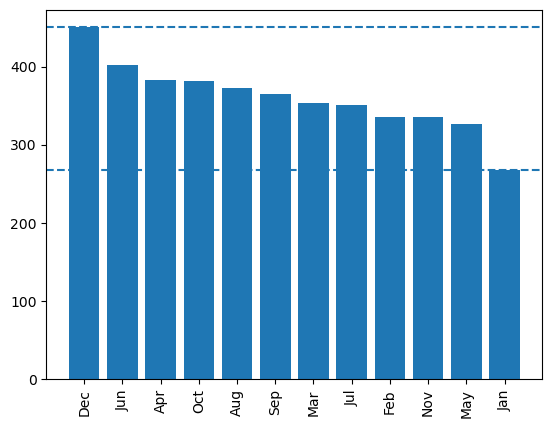

In [254]:
max_value =popular["total"].max()
min_value =popular["total"].min()
plt.figure()
graph = plt.bar(popular[0],popular["total"])
plt.axhline(max_value, linestyle='--')
plt.axhline(min_value, linestyle='--')

plt.xticks(rotation=90)
plt.show()


# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

In [255]:
_Price = df_data[df_data.Price > 5]
launch_price = _Price.groupby('Date')["Price"].sum().reset_index(name="Total")
launch_price['Date'] = launch_price["Date"].astype("string").str.split(",").apply(lambda x: x[1][0:5])

final_launch_prices= launch_price.groupby("Date")["Total"].sum().reset_index(name="Total")



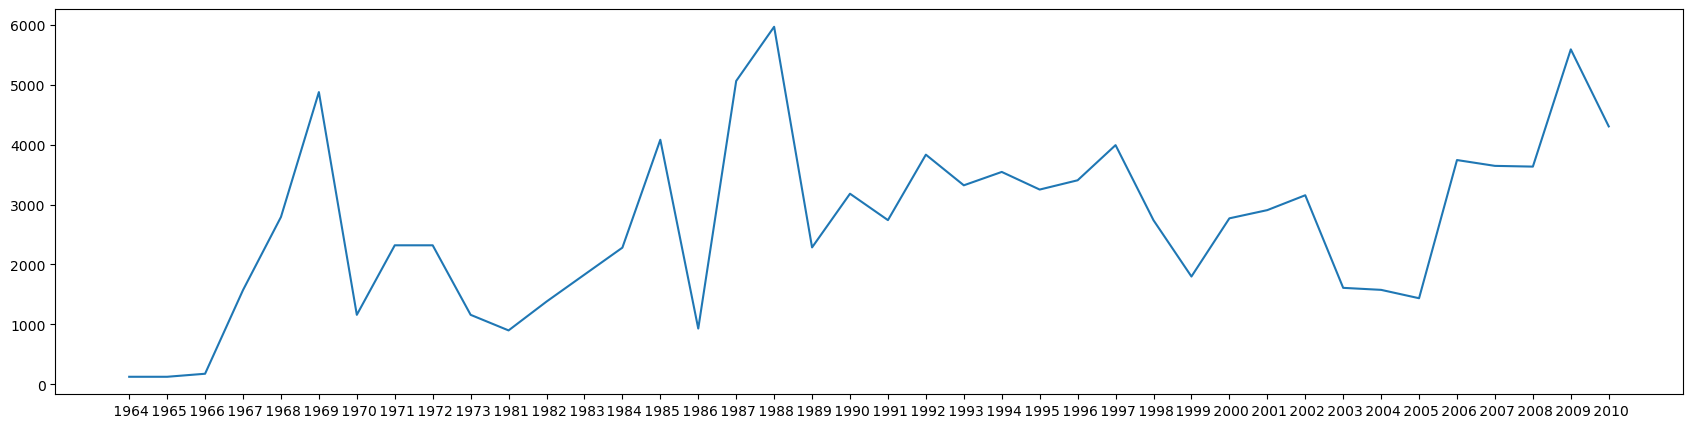

In [277]:
plt.figure(figsize=(21,5))
plt.plot(final_launch_prices["Date"][:-10],final_launch_prices["Total"][:-10])


# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

In [257]:

initial = df_data[["Date","Organisation"]]
initial["Date"] =initial["Date"].astype("string").str.split(",").apply(lambda x: x[1][0:5])
initial = initial.groupby(["Organisation","Date"])["Date"].count().reset_index(name = "Total")
initial = initial.sort_values("Total",ascending=False)

initial

C:\Users\hp\AppData\Local\Temp\ipykernel_17492\2567075350.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Organisation,Date,Total
517,RVSN USSR,1977,97
516,RVSN USSR,1976,95
511,RVSN USSR,1971,93
515,RVSN USSR,1975,89
510,RVSN USSR,1970,87
...,...,...,...
619,US Air Force,1981,1
620,US Air Force,1982,1
621,US Air Force,1983,1
622,US Air Force,1984,1


Text(0, 0.5, 'Total Launches')

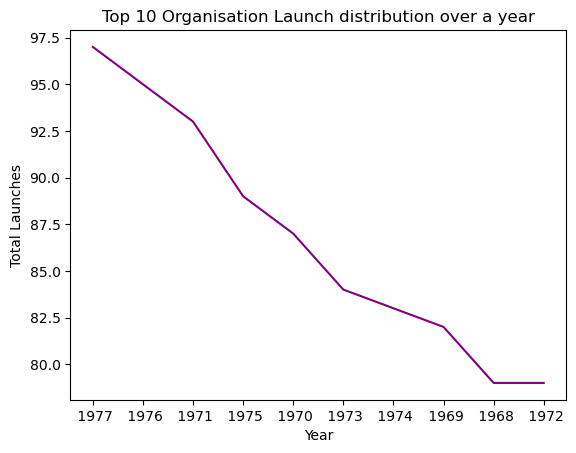

In [258]:
plt.plot(initial["Date"][:10],initial["Total"][:10],color="purple")
plt.title("Top 10 Organisation Launch distribution over a year")
plt.xlabel("Year")
plt.ylabel("Total Launches")


## Create a Plotly Pie Chart comparing the total number of launches of the Kazakhstan and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [259]:
country_cluster = df_data[["Country","Date"]]
country_cluster["Date"]= country_cluster["Date"].astype("string").str.split(",").apply(lambda x: x[1][0:5])
country_cluster = country_cluster.groupby(["Country"])["Date"].count().reset_index(name="Total Launches")
country_cluster = country_cluster.sort_values(by= "Total Launches",ascending=False)
country_cluster

C:\Users\hp\AppData\Local\Temp\ipykernel_17492\1674727572.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Country,Total Launches
17,Russia,1395
20,USA,1344
10,Kazakhstan,701
4,France,303
3,China,268
9,Japan,126
6,India,76
16,Pacific Ocean,36
13,New Zealand,13
7,Iran,13


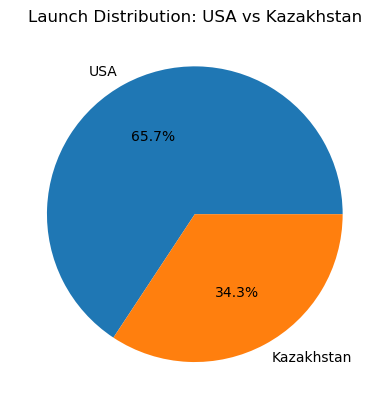

In [260]:
final_figure = country_cluster[(country_cluster["Country"].isin(["USA","Kazakhstan"]))]

plt.pie(final_figure["Total Launches"],labels = final_figure.Country, autopct='%1.1f%%')
plt.title("Launch Distribution: USA vs Kazakhstan")

plt.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [261]:
raw_date = df_data["Date"].astype("string").str.split(",").apply(lambda x: x[1][:5])

yearly_launches= raw_date.value_counts().reset_index(name="total")
yearly_launches = yearly_launches.sort_values(by="Date",ascending=False)
# yearly_launches.duplicated().any()
yearly_launches

,Date,total
28,2020,63
5,2019,109
1,2018,117
15,2017,92
16,2016,90
...,...,...
43,1961,52
57,1960,39
62,1959,20
61,1958,28


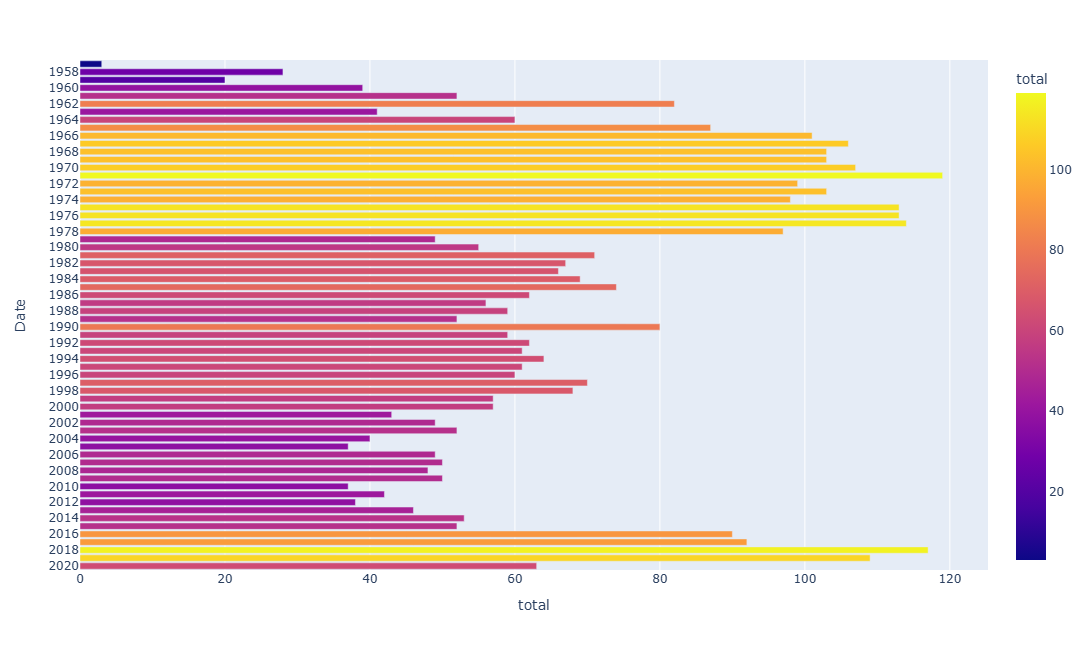

<Figure size 1100x1200 with 0 Axes>

In [262]:
plt.figure(figsize=(11,12))
fig = px.bar(yearly_launches,x=yearly_launches["total"],y= yearly_launches["Date"],color='total',
             hover_data=['Date', 'total'],
             labels={'pop':'yearly launches distribution'}, height=650)
fig.show()

## Chart the Total Number of Mission Failures Year on Year.

In [263]:
mission_stat = df_data[["Date","Mission_Status"]]
mission_stat["Date"] = mission_stat["Date"].astype("string").str.split(",").apply(lambda x: x[1][:5])
final_status = mission_stat.groupby(["Date","Mission_Status"])["Mission_Status"].count().reset_index(name="total")

# final_status 
fail_fig = final_status.query("Mission_Status in ['Failure','Partial Failure','Prelaunch Failure']")
fail_count = fail_fig.groupby("Mission_Status").size().reset_index(name="total")
fail_count

C:\Users\hp\AppData\Local\Temp\ipykernel_17492\3168538442.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Mission_Status,total
0,Failure,64
1,Partial Failure,46
2,Prelaunch Failure,4


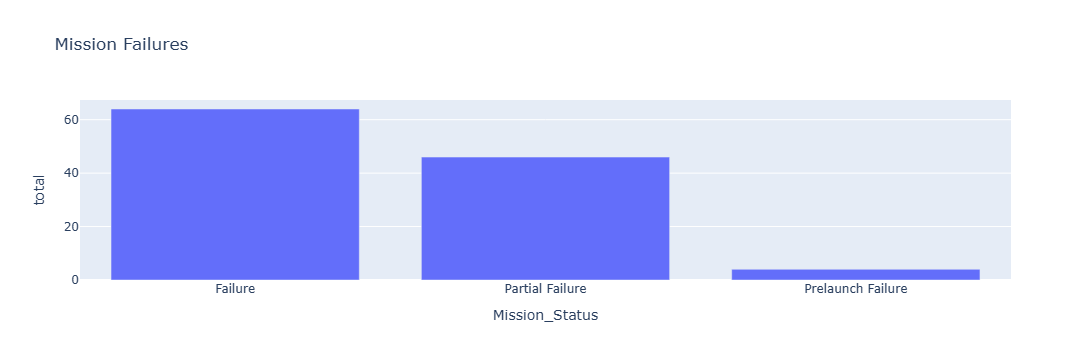

In [264]:

px.bar(fail_count, x="Mission_Status", y="total", title="Mission Failures")


## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

In [265]:
init_fail = df_data[["Date","Mission_Status"]]
init_fail["Date"] = init_fail["Date"].astype("string").str.split(",").apply(lambda x: x[1][1:5])
Total_failure = init_fail.groupby(["Date","Mission_Status"])["Mission_Status"].count().reset_index(name="Total")

Total_failure = Total_failure.query("Mission_Status == 'Failure'")
Total_failure= Total_failure.query("Total > 4") 

C:\Users\hp\AppData\Local\Temp\ipykernel_17492\4065654830.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



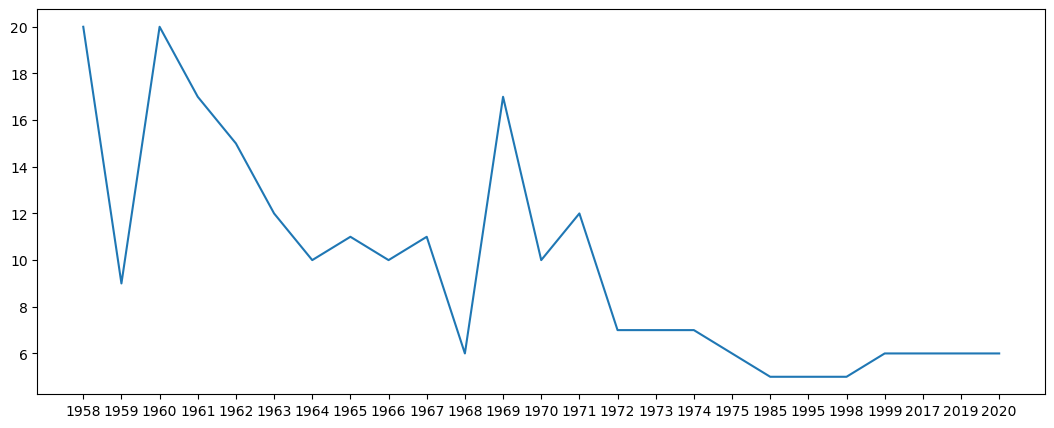

In [266]:
plt.figure(figsize=(13,5))
figs = plt.plot(Total_failure["Date"],Total_failure["Total"])


# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and  including 2020)

Do the results change if we only look at the number of successful launches? 

In [267]:

Total_success =init_fail.groupby(["Date","Mission_Status"])["Mission_Status"].count().reset_index(name="Total")
Total_success = Total_success.query("Mission_Status == 'Success' and Total > 15")
Total_success

,Date,Mission_Status,Total
9,1960,Success,19
12,1961,Success,32
15,1962,Success,65
17,1963,Success,29
20,1964,Success,48
...,...,...,...
165,2016,Success,86
168,2017,Success,84
171,2018,Success,113
175,2019,Success,100


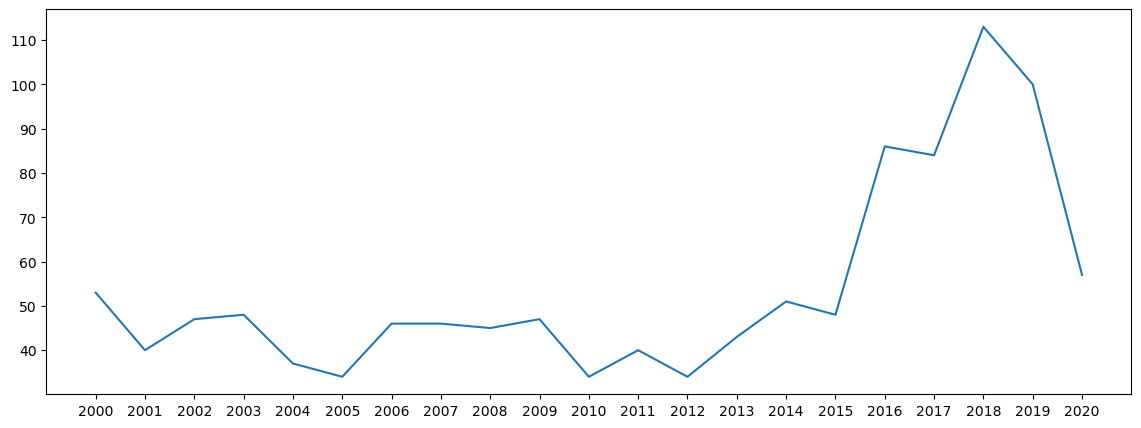

In [268]:
plt.figure(figsize=(14,5))
plt.plot(Total_success["Date"][40:],Total_success["Total"][40:])

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [269]:
init_launches = df_data[["Organisation","Date"]]
init_launches["Date"] = init_launches["Date"].astype("string").str.split(",").apply(lambda x: x[1][1:5])
Total_num_launches = init_launches.groupby(["Date","Organisation"])["Organisation"].count().reset_index(name="Total")
Total_num_launches.head(40)
                        

C:\Users\hp\AppData\Local\Temp\ipykernel_17492\1272333249.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Date,Organisation,Total
0,1957,RVSN USSR,2
1,1957,US Navy,1
2,1958,AMBA,7
3,1958,NASA,2
4,1958,RVSN USSR,5
5,1958,US Air Force,2
6,1958,US Navy,12
7,1959,General Dynamics,1
8,1959,NASA,1
9,1959,RVSN USSR,4


In [270]:
max_launches = Total_num_launches.loc[
    Total_num_launches.groupby("Date")["Total"].idxmax()
]
max_launches

,Date,Organisation,Total
0,1957,RVSN USSR,2
6,1958,US Navy,12
10,1959,US Air Force,10
15,1960,US Air Force,21
19,1961,US Air Force,23
...,...,...,...
583,2016,CASC,22
611,2017,SpaceX,18
616,2018,CASC,37
632,2019,CASC,27


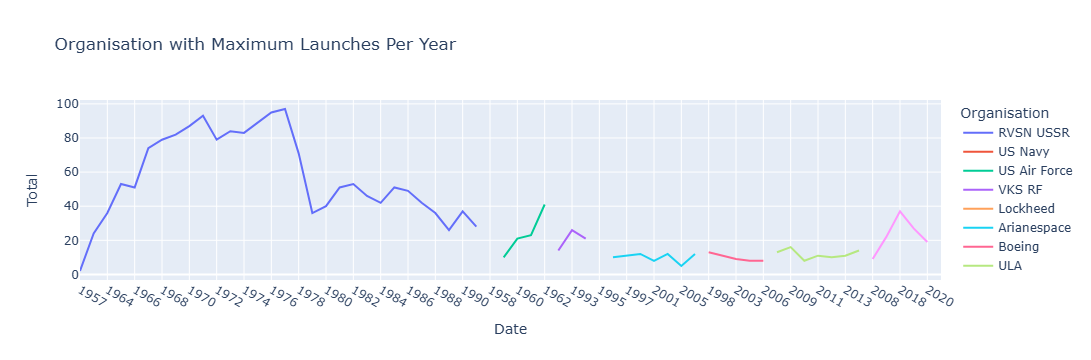

In [271]:
fig = px.line(
    max_launches,
    x="Date",
    y="Total",
    color="Organisation",
    title="Organisation with Maximum Launches Per Year"
)

fig.show()